# 11 · From an LSST alert to a ranked answer

One alert in, one answer out: which supernova model the data prefer and how strongly, how far to
trust each fit, what the transient will do next, and which observation would tell the leading models
apart. It all ends up in a facts file and a self-contained HTML report.

The alert here is simulated from a known supernova, so the last section can check the answer against
the truth. In this run:

* **`arnett`, the model the alert was made from, ranks first**, with a "strong" preference over
  `magnetar` (weight about 0.98).
* The explosion time comes back within an hour of the true one, and the nickel mass within its 68 %
  interval.
* The whole notebook takes about six minutes on one GPU.

**Needs:** the `[gpu]` extra, and `source "$(whisper-cbpf-env)"` before Python starts. It also runs
on the CPU, several times slower.

> **Budgets here are illustrative, not publication-grade.** The diagnostics below say how much
> longer a publication run needs.

In [1]:
import tempfile
from pathlib import Path

# float64 must be switched on BEFORE the first JAX array exists: every supernova model needs it.
import jax
jax.config.update("jax_enable_x64", True)

import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import whisper_cbpf as wp

OUT = Path(tempfile.mkdtemp(prefix="whisper_alert_"))    # the facts file and the report go here
print("whisper_cbpf", wp.__version__, "| x64:", wp.x64_enabled(), "| devices:", jax.devices())

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/opt/venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 496, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/opt/venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 369, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/opt/venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 273, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


whisper_cbpf 0.2.0 | x64: True | devices: [CpuDevice(id=0)]


## 1 · The alert

A Rubin alert packet carries the newest detection (`diaSource`), the earlier detections of the same
object (`prvDiaSources`) and forced photometry at earlier visits (`prvDiaForcedSources`). Fluxes are
difference-image PSF fluxes in nJy.

This one is simulated: a Type Ia-like Arnett supernova at redshift 0.05 (0.42 solar masses of
nickel), observed every 2-3 days in g, r and i with single-visit 5-sigma depths of 24.6, 24.3 and
23.8 mag. Three forced-photometry visits before the explosion saw nothing.

In [2]:
from whisper_cbpf.models.cosmology import luminosity_distance_cm

Z = 0.05                                          # the host galaxy's redshift
T_EXPLOSION = 61000.3                             # MJD
TRUTH = {"f_nickel": 0.3, "mej": 1.4, "vej": 1.0e4, "kappa": 0.1, "kappa_gamma": 0.03,
         "temperature_floor": 3000.0}
BANDS = ["lsstg", "lsstr", "lssti"]
DEPTH = {"lsstg": 24.6, "lsstr": 24.3, "lssti": 23.8}  # single-visit 5-sigma depths, AB mag

truth_model = wp.supernova_model("arnett", BANDS, redshift=Z, dl_cm=float(luminosity_distance_cm(Z)))
rng = np.random.default_rng(42)


def visit_error(band, flux_njy=0.0):
    # Sky noise at the 5-sigma depth, plus 1 % of the source flux.
    sky = 10 ** ((31.4 - DEPTH["lsst" + band]) / 2.5) / 5.0
    return np.hypot(sky, 0.01 * flux_njy)


# Detections: a revisit every 2-3 days, rotating through g, r and i.
t_det = np.array([61001.4, 61003.2, 61004.3, 61006.2, 61008.4, 61010.3, 61012.2, 61013.4,
                  61015.3, 61018.2, 61020.4, 61023.3, 61026.2, 61029.4])
b_det = np.array(["r", "g", "i", "r", "g", "r", "i", "g", "r", "i", "g", "r", "i", "r"])
true_njy = 1e9 * np.asarray(truth_model.predict(TRUTH, t_det - T_EXPLOSION,
                                                np.char.add("lsst", b_det)), float)
err = np.array([visit_error(b, f) for b, f in zip(b_det, true_njy)])
sources = [{"diaSourceId": 100 + i, "visit": 500 + i, "midpointMjdTai": float(t), "band": str(b),
            "psfFlux": float(f + e * rng.standard_normal()), "psfFluxErr": float(e)}
           for i, (t, b, f, e) in enumerate(zip(t_det, b_det, true_njy, err))]

# Forced photometry before the explosion: flux consistent with zero.
t_pre, b_pre = [60991.3, 60995.2, 60998.3], ["r", "g", "r"]
forced = [{"diaForcedSourceId": 200 + i, "visit": 400 + i, "midpointMjdTai": t, "band": b,
           "psfFlux": float(visit_error(b) * rng.standard_normal()), "psfFluxErr": float(visit_error(b))}
          for i, (t, b) in enumerate(zip(t_pre, b_pre))]

alert = {"diaObject": {"diaObjectId": 3141592653589},
         "diaSource": sources[-1], "prvDiaSources": sources[:-1], "prvDiaForcedSources": forced}
print(f"{len(sources)} detections and {len(forced)} forced-photometry visits;",
      f"newest: {alert['diaSource']['band']} band, {alert['diaSource']['psfFlux']:.0f} nJy")

00:54 redback WARNING : No module named 'lalsimulation'


00:54 redback WARNING : lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model


00:54 bilby INFO    : Running bilby version: 2.8.2


00:54 redback INFO    : Running redback version: 1.20.0


14 detections and 3 forced-photometry visits; newest: r band, 159038 nJy


## 2 · Load it

`survey="lsst"` applies the survey's photometry rule: the PSF flux on the difference image becomes an
AB magnitude, `m = 31.4 - 2.5 log10(psfFlux / nJy)`; a forced-photometry visit without a detection
becomes a 5-sigma upper limit; negative, flagged and duplicate rows are dropped and counted; bands are
labelled `lsstg`, `lsstr`, `lssti`. The redshift is the host galaxy's. Leave it out when there is
none, and every model fits it instead.

In [3]:
lc = wp.load_lightcurve(alert, survey="lsst", redshift=Z)

n_lim = int(np.sum(lc["upper_limit"]))
print(f"object {lc.name}: {lc.n_points} rows = {lc.n_points - n_lim} detections + {n_lim} upper limits")
print("bands:", lc.bands, "| redshift:", lc.redshift)
print("first detection: MJD", lc.meta["first_detection_mjd"])
print("photometry:", lc.meta["photometry"])
print("rows dropped:", {k: v for k, v in lc.meta["n_dropped"].items() if v} or "none")
lc.to_dataframe()[["time", "band", "magnitude", "magnitude_err", "upper_limit"]].round(3)

object 3141592653589: 17 rows = 14 detections + 3 upper limits
bands: ['lsstg', 'lssti', 'lsstr'] | redshift: 0.05
first detection: MJD 61001.4
photometry: LSST diaSource difference-image PSF flux as AB magnitude, m = 31.4 - 2.5 log10(psfFlux / nJy); scienceFlux is not used
rows dropped: none


,time,band,magnitude,magnitude_err,upper_limit
0,60991.3,lsstr,24.300,NaN,True
1,60995.2,lsstg,24.600,NaN,True
2,60998.3,lsstr,24.300,NaN,True
3,61001.4,lsstr,23.123,0.074,False
4,61003.2,lsstg,20.974,0.013,False
5,61004.3,lssti,20.639,0.016,False
6,61006.2,lsstr,19.705,0.011,False
7,61008.4,lsstg,19.078,0.011,False
8,61010.3,lsstr,18.831,0.011,False
9,61012.2,lssti,18.700,0.011,False


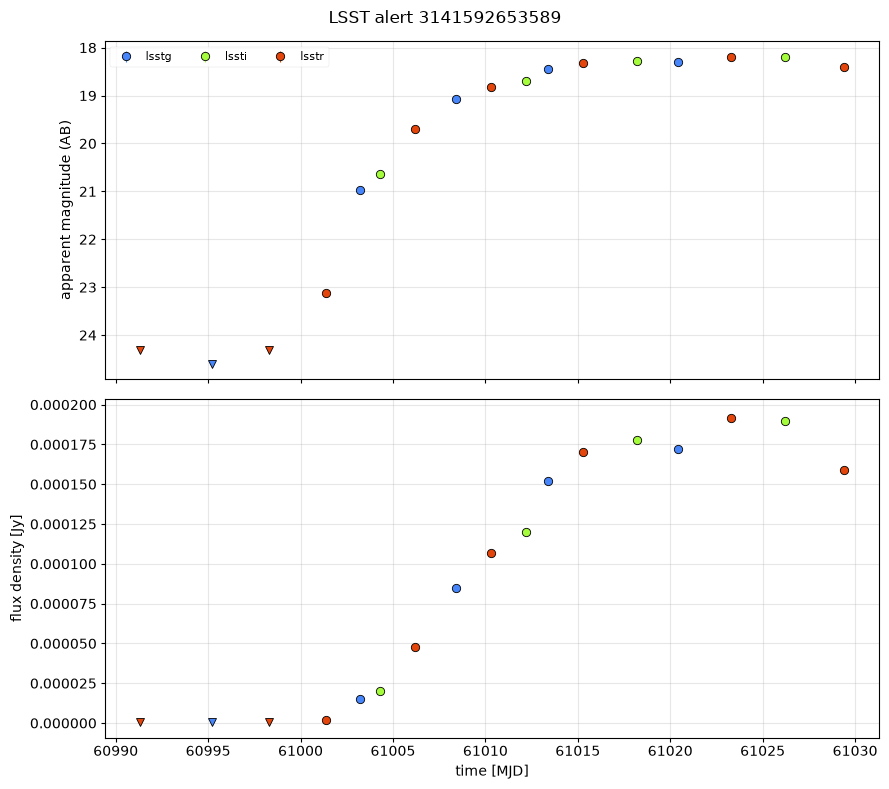

In [4]:
axes = wp.plot_light_curve(lc, title=f"LSST alert {lc.name}")
plt.show()

## 3 · Compare three supernova families

`compare` takes the light curve and model names. Each family name is bound to this alert: its bands,
the host redshift, and a free explosion time whose prior runs from the last non-detection to the
first detection. The three limits before the explosion are not fitted; they only set that prior.
Every model is then fitted, its likelihood peak is found, its convergence is checked, and the models
are ranked.

The settings, one line each:

* **`sampler="auto"`** (the default) runs `emcee_jax` on the GPU, or the CPU `mcmc` without one.
* **`init="prior"`** starts every walker at its own prior draw. This light curve also has a poorer
  solution, with about 2.4 solar masses of nickel instead of 0.4. Starts spread over the whole prior
  box reach the better peak, and any walker left behind is named in the diagnostics.
* **`evidence_check=False`** skips the nested-sampling check of the top two models. It costs about
  ten CPU minutes per model; `"auto"` runs it when the top two are close.

In [5]:
FAMILIES = ["arnett", "magnetar", "csm_shock_arnett"]
cmp = wp.compare(lc, FAMILIES, init="prior", nwalkers=64, nsteps=10000, burnin=5000,
                 evidence_check=False, seed=0)
print(cmp.summary())

Comparison of 3 models on 14 points by BIC: winner 'arnett' (strong over 'magnetar', ln B = 4.27)

  rank  model             sampler  k   n   max ln L  BIC     ln Z  dBIC   weight  grade     converged
  1     arnett            mcmc     7   14  44.48     -70.49  -     0.00   0.981   strong    no
  2     magnetar          mcmc     10  14  44.17     -61.95  -     8.54   0.014   strong    no
  3     csm_shock_arnett  mcmc     11  14  44.48     -59.94  -     10.56  0.005   decisive  no

Caveats:
  - the winner's fit ('arnett') did not pass its convergence report (its failed checks are listed below). Its likelihood maximum and BIC stand; do not quote its error bars from this run.
  - arnett: chain length / autocorrelation time: the chain is 11.7 autocorrelation times long (largest tau 854 steps), below 50: too short to trust. Raise nsteps to at least 42680; split R-hat across walkers (largest): R-hat 1.787 on 'kappa': the walkers disagree about where the posterior is. Run longer, and look fo

## 4 · The ranking

With no nested-sampling evidence, the models are ranked by BIC, `-2 ln L_max + k ln n`: lower is
better. Weights are `exp(-dBIC/2)`, normalised, and the grade is Jeffreys' scale on the Bayes factor
that dBIC/2 approximates. A dBIC above 4.6 is "strong" and above 9.2 "decisive".

All three models reach nearly the same `max ln L`: the magnetar and CSM families can reproduce an
Arnett light curve, so these 14 points cannot tell them apart by fit quality alone. What decides is
BIC's charge for parameters the data do not need.

In [6]:
cols = ["model", "n_params", "n_data", "max_log_likelihood", "bic", "delta", "weight", "grade"]
cmp.table[cols].round(3)

,model,n_params,n_data,max_log_likelihood,bic,delta,weight,grade
0,arnett,7,14,44.484,-70.495,0.000,0.981,strong
1,magnetar,10,14,44.171,-61.952,8.543,0.014,strong
2,csm_shock_arnett,11,14,44.484,-59.939,10.556,0.005,decisive


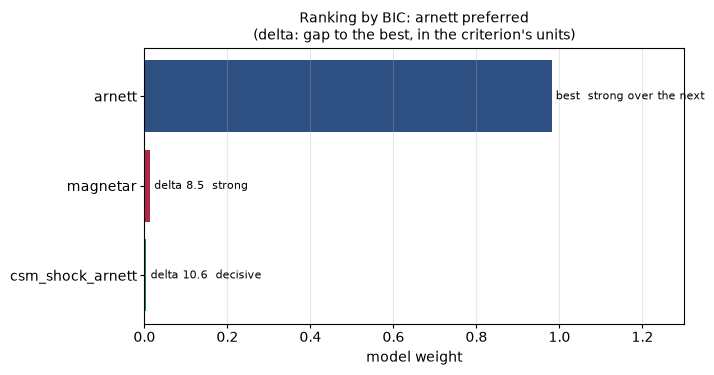

In [7]:
ax = wp.plot_model_comparison(cmp)
plt.show()

### The peak behind each BIC

BIC is defined at the *maximum* of the likelihood. A sampler maps the bulk of the posterior and
rarely lands exactly on its summit, and how far short it stops differs from model to model, so its
best draw would put sampler noise into the ranking. `compare` therefore climbs from each fit's best
draws to the peak (`wp.likelihood_max_opt`, a maximum-likelihood optimisation) and takes AIC and
BIC from there. The posterior itself (draws, medians, error bars) is not changed. The gain is how
far below the peak the sampler's best draw was. A gain above about 1 means the sampler never
reached the peak, and ranking on its best draw would have been off by twice that in BIC.

In [8]:
pd.DataFrame([{"model": m, "sampler's best ln L": p.start_log_likelihood,
               "peak ln L": p.max_log_likelihood, "gain": p.gain, "BIC at the peak": p.bic,
               "on a prior edge": ", ".join(p.at_edge) or "-"}
              for m, p in cmp.peaks.items()]).round(3)

,model,sampler's best ln L,peak ln L,gain,BIC at the peak,on a prior edge
0,arnett,44.428,44.484,0.056,-70.495,-
1,magnetar,43.755,44.171,0.416,-61.952,-
2,csm_shock_arnett,44.419,44.484,0.065,-59.939,-


## 5 · Can the fits be trusted?

Each fit carries a convergence report: stuck walkers, chain length against the autocorrelation time,
split R-hat, effective sample sizes, pile-up at a prior edge and the gap to the likelihood peak.
Each check passes or fails with a plain reason.

In [9]:
print(cmp.diagnostics[cmp.winner])

Diagnostics of the mcmc fit of 'arnett': FAILED (4 of 9 checks)
  check                                 value    threshold                                        result
  posterior draws                       32000    > 0                                              pass
  data points                           14       > 7 (free parameters)                            pass
  stuck walkers                         0        none                                             pass
  chain length / autocorrelation time   11.72    >= 50 (largest tau)                              FAIL
  split R-hat across walkers (largest)  1.787    < 1.05                                           FAIL
  bulk ESS (smallest)                   96.41    >= 400                                           FAIL
  tail ESS (smallest)                   118      >= 400                                           FAIL
  prior-edge pile-up                    0.04813  <= 5% of draws in the outer 1% of a prior range  pass
  gap t

Read this in two parts. The **ranking stands**: it rests on each model's likelihood peak, found by
climbing from the best of walkers that started all over the prior box, and the small gap between the
sampler's best draw and the peak says the chains did find it. The **error bars do not yet**: some
walkers never left poor regions of the prior box, their draws are pooled into the posterior, and the
chain is short against its autocorrelation time. The next section maps the posteriors again,
starting from each peak.

## 6 · Error bars: a second pass from each peak

The top two models are fitted again, each starting in a small ball around its likelihood peak
(`init=` a point; the ball is 0.1 % of each prior's width), so every walker starts in the solution
the ranking was built on.

In [10]:
refits = {}
for name in cmp.table["model"][:2]:
    refits[name] = wp.fit(lc, cmp.models[name], sampler="emcee_jax", nwalkers=64, nsteps=20000,
                          burnin=5000, init=cmp.peaks[name].params, seed=0)
    rows = {row.check: row for row in refits[name].diagnostics().rows}
    tau = rows["chain length / autocorrelation time"]
    print(f"{name:10s} best ln L {refits[name].max_log_likelihood:6.2f} "
          f"(peak {cmp.peaks[name].max_log_likelihood:.2f})   "
          f"chain / autocorrelation time: {tau.value:.1f} (a trustworthy chain needs >= 50)")

arnett     best ln L  44.46 (peak 44.48)   chain / autocorrelation time: 13.3 (a trustworthy chain needs >= 50)


magnetar   best ln L  44.06 (peak 44.17)   chain / autocorrelation time: 10.3 (a trustworthy chain needs >= 50)


Both chains map the solution of their peak. They are still short against their autocorrelation time,
because on 14 points the nickel fraction, ejecta mass and opacity trade off along a ridge, and
`refits[name].diagnostics()` gives the chain length a publication run needs. The medians already
sit where the data put them.

## 7 · The models over the data

Each model's posterior median and 68 % band, in magnitudes, with the residuals underneath. The open
grey squares are the pre-explosion limits: plotted, not fitted.

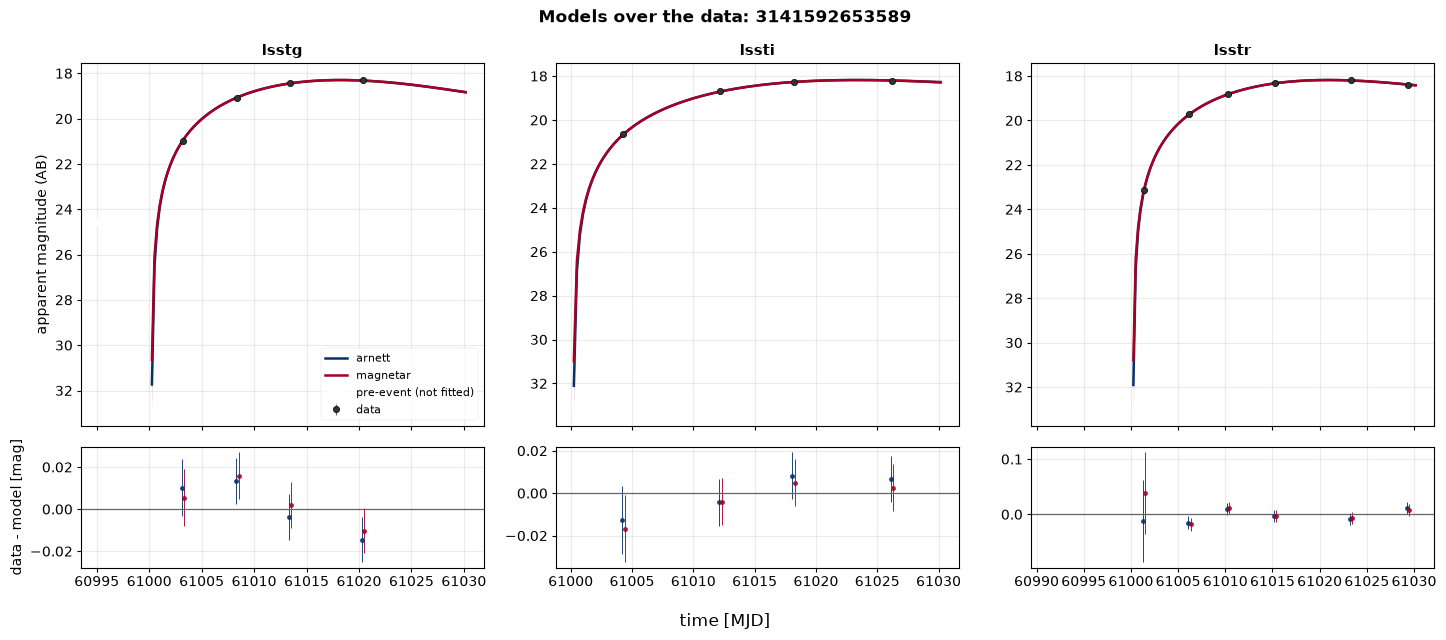

In [11]:
axes = wp.plot_models(refits, lc)
plt.show()

Both models trace every point to within a few hundredths of a magnitude. On the data alone they are
indistinguishable, which is why the ranking comes down to the number of parameters. The widths below
say which parameters the data constrained.

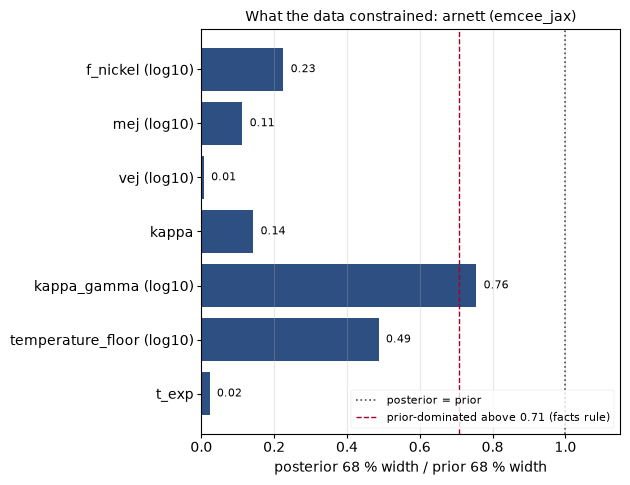

In [12]:
winner = cmp.winner
ax = wp.plot_widths(refits[winner])
plt.show()

Each bar is the posterior's 68 % width over the prior's, in the prior's own coordinate (log10 for a
log-uniform prior). The ejecta velocity and the explosion time are pinned down; the gamma-ray opacity
`kappa_gamma` is prior-dominated, because a month of data barely sees gamma-ray escape.

## 8 · What happens next

`forecast` draws from the posterior and predicts each band on a grid of future epochs: the median,
the spread, percentiles and the fraction of draws too faint to detect. `discriminate` asks where two
models differ most, measured against their spreads and the survey's photometric error at the given
depth.

In [13]:
FUTURE = np.arange(61030.0, 61061.0, 2.0)          # the next month, every two days
fc = wp.forecast(refits[winner], FUTURE, BANDS, lc=lc, survey_depth=DEPTH)
fc[["time", "band", "mean_mag", "sd_mag", "q16", "q84", "frac_too_faint"]].head(6).round(3)

,time,band,mean_mag,sd_mag,q16,q84,frac_too_faint
0,61030.0,lsstg,18.806,0.052,18.729,18.845,0.0
1,61030.0,lsstr,18.412,0.012,18.400,18.423,0.0
2,61030.0,lssti,18.287,0.036,18.260,18.343,0.0
3,61032.0,lsstg,18.934,0.081,18.807,18.992,0.0
4,61032.0,lsstr,18.495,0.019,18.479,18.508,0.0
5,61032.0,lssti,18.343,0.049,18.305,18.421,0.0


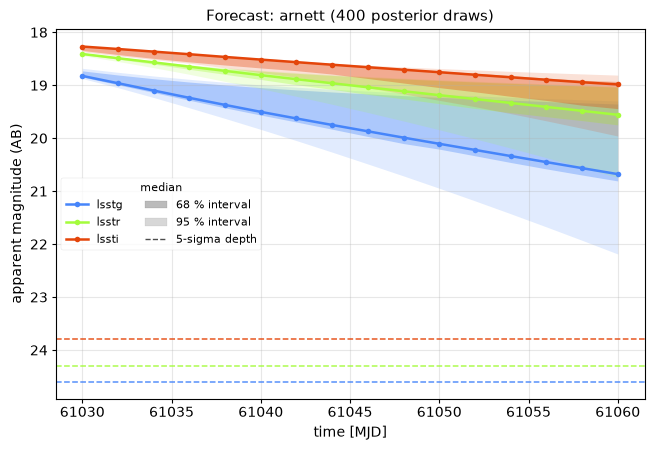

In [14]:
ax = wp.plot_forecast(fc)
plt.show()

In [15]:
d = wp.discriminate(refits, FUTURE, BANDS, survey_depth=DEPTH)
best = d.attrs["best"]
print(f"most telling observation: {best['band']} at MJD {best['time']:.0f}: "
      f"{best['model_a']} predicts {best['mean_a']:.2f}, {best['model_b']} {best['mean_b']:.2f} mag "
      f"(D = {best['D']:.1f} combined sigma)")
d.sort_values("D", ascending=False)[["time", "band", "mean_a", "mean_b", "D", "observable"]].head(5).round(3)

most telling observation: lssti at MJD 61050: arnett predicts 18.84, magnetar 19.18 mag (D = 1.2 combined sigma)


,time,band,mean_a,mean_b,D,observable
32,61050.0,lssti,18.842,19.177,1.225,True
29,61048.0,lssti,18.789,19.073,1.224,True
35,61052.0,lssti,18.894,19.282,1.214,True
26,61046.0,lssti,18.736,18.972,1.205,True
38,61054.0,lssti,18.946,19.388,1.197,True


`D` counts combined standard deviations: the gap between the two predictions over their posterior
spreads and the photometric error at the survey depth. The two models agree closely for the next
two weeks; after that `arnett` fades more slowly than `magnetar`, most clearly in i. At D near 1 a
single visit leans one way without deciding, so a few i-band visits over those weeks are what would
tell the two apart.

## 9 · The facts file

`facts()` collects every number above as JSON, each computed by a stated rule and recomputable from
the saved inputs: the ranking and grades, per-parameter medians and widths, what the data show band by
band, and caveats as true or false. A person reads it in the report; a program reads the same file.

In [16]:
facts = cmp.facts()
print(facts["ranking"]["reading"])
print()
caveats = facts["caveats"]
print("winner converged          :", caveats["winner_converged"])
print("prior-dominated (winner)  :", caveats["winner_prior_dominated_parameters"])
print("models with stuck walkers :", caveats["models_with"]["stranded_walkers"])
print("models left out           :", caveats["models_left_out"] or "none")
print()
for band, row in facts["data"]["per_band"].items():
    print(f"  {band}: {row['state']}")
path = wp.write_facts(facts, OUT)
print()
print("wrote", path.name, f"({path.stat().st_size / 1024:.0f} kB), sha256", facts["sha256"][:12])

arnett is preferred over magnetar by delta BIC = 8.5 (ln B = 4.27: strong); weight 0.981

winner converged          : False
prior-dominated (winner)  : ['kappa_gamma']
models with stuck walkers : ['csm_shock_arnett', 'magnetar']
models left out           : none

  lsstg: rising
  lsstr: peaked
  lssti: rising

wrote facts.json (66 kB), sha256 869568a9d533


## 10 · The report

One call writes a single HTML file with everything inline: the answer and its caveats, the ranking,
the figures, the parameters, what the data show, the diagnostics and the provenance. It needs no
network and no script, so it can be mailed or archived as it is.

In [17]:
import re

html = cmp.report(OUT)
text = html.read_text()
print("wrote", html.name, f"({html.stat().st_size / 1e6:.1f} MB)")
print("sections:", [re.sub("<[^>]+>", "", h) for h in re.findall(r"<h2[^>]*>(.*?)</h2>", text)])

wrote report.html (0.9 MB)
sections: ['Answer', 'Ranking', 'Figures', 'Parameters', 'What the data show', 'Diagnostics', 'Forecast', 'Provenance']


## 11 · Against the truth

The alert was made from `arnett` with known parameters. Each quantity below is compared with the
truth: the explosion time and velocity; the nickel mass `f_nickel * mej`, which sets the peak
brightness; `kappa * mej`, which sets the diffusion time and so the width of the peak; and `kappa`
on its own.

In [18]:
s = refits["arnett"].samples
checks = {"t_exp [MJD]": (s["t_exp"], T_EXPLOSION),
          "vej [km/s]": (s["vej"], TRUTH["vej"]),
          "nickel mass [Msun]": (s["f_nickel"] * s["mej"], TRUTH["f_nickel"] * TRUTH["mej"]),
          "kappa * mej [Msun cm2/g]": (s["kappa"] * s["mej"], TRUTH["kappa"] * TRUTH["mej"]),
          "kappa [cm2/g]": (s["kappa"], TRUTH["kappa"])}
rows = []
for name, (draws, true) in checks.items():
    lo, med, hi = np.percentile(draws, [16, 50, 84])
    rows.append({"quantity": name, "truth": true, "median": med, "16%": lo, "84%": hi,
                 "truth inside 68 %": bool(lo <= true <= hi)})
pd.DataFrame(rows).round(4)

,quantity,truth,median,16%,84%,truth inside 68 %
0,t_exp [MJD],61000.30,61000.2922,61000.2674,61000.3154,True
1,vej [km/s],10000.00,10044.3907,9933.1550,10153.7321,True
2,nickel mass [Msun],0.42,0.4186,0.4151,0.4242,True
3,kappa * mej [Msun cm2/g],0.14,0.1428,0.1388,0.1471,True
4,kappa [cm2/g],0.10,0.1944,0.1015,0.2906,False


The winner is the model the alert was made from, and the quantities a month of photometry measures
(the explosion time, the velocity and the two products) come back around the truth. `kappa` on its
own does not: the light curve fixes `kappa * mej` and `f_nickel * mej`, which leaves one direction
free along which the opacity, the ejecta mass and the nickel fraction trade off.

## Where next

* [08 · Metrics and model comparison](08_metrics_and_comparison.ipynb): what AIC, BIC, WAIC and ln Z
  mean, and when not to compare them.
* [`docs/MODEL_COMPARISON.md`](../docs/MODEL_COMPARISON.md): comparing physical models, with the
  evidence check.
* [01 · Light curves](01_light_curves.ipynb): the ZTF preset (`survey="ztf"`) and other formats.